# 사과와 배 딥러닝으로 분류하기

- 데이터를 기반으로 사과인지 배인지를 딥러닝으로 분류하기(이진 분류)
- 여러 개의 층을 갖는 딥러닝 모델 만들기(DNN)

### 데이터 준비

#### 데이터 칼럼 설명
- fruit : 과일 종류
- weight : 과일 무게
- height : 세로 길이
- width : 가로 길이
- hardness : 단단한 정도
- sweet : 당도
- sour : 산도
- color : 착색도
- 데이터 출처 : 농업 진흥청 국립원예특작과학원 과수생육품질관리시스템(https://fruit.nihhs.go.kr/)

In [1]:
import pandas as pd

df = pd.read_excel('사과배-학습.xlsx')
df.fillna(0, inplace=True)
df.replace({'fruit':{'사과':0, '배':1}}, inplace=True)
x_train = df.iloc[:, 1:]  
y_train = df.iloc[:,0]    

### 딥러닝 모델 구성
- 3개 층을 갖는 모델을 구성

In [2]:
# 딥러닝을 위한 라이브러리 import
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
tf.random.set_seed(0)

In [3]:
# 모델 생성
model = Sequential()

# 층 쌓기
model.add(Dense(units=6,input_shape=(7,),activation='relu'))
model.add(Dense(units=3,activation='relu'))

# 출력층의 출력 노드는 3개([사과, 배, 복숭아])
# softmax : 0과 1 사이의 특징을 도드라지게 하는 활성함수 적용
model.add(Dense(units=1,activation='sigmoid'))

#학습 과정 설정
model.compile(optimizer = 'Adam', loss = 'binary_crossentropy', 
               metrics=['accuracy'])     
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 6)                 48        
                                                                 
 dense_1 (Dense)             (None, 3)                 21        
                                                                 
 dense_2 (Dense)             (None, 1)                 4         
                                                                 
Total params: 73
Trainable params: 73
Non-trainable params: 0
_________________________________________________________________


In [4]:
# 학습 실행
history = model.fit(x_train,y_train,epochs=50)
# verbose=0 : 학습 진행 상황 생략

Epoch 1/50
3/3 [==============================] - 0s 3ms/step - loss: 47.9986 - accuracy: 0.6421
Epoch 2/50
3/3 [==============================] - 0s 0s/step - loss: 45.8634 - accuracy: 0.6421
Epoch 3/50
3/3 [==============================] - 0s 0s/step - loss: 43.8419 - accuracy: 0.6421
Epoch 4/50
3/3 [==============================] - 0s 5ms/step - loss: 41.7653 - accuracy: 0.6421
Epoch 5/50
3/3 [==============================] - 0s 0s/step - loss: 39.6926 - accuracy: 0.6421
Epoch 6/50
3/3 [==============================] - 0s 0s/step - loss: 37.6338 - accuracy: 0.6421
Epoch 7/50
3/3 [==============================] - 0s 0s/step - loss: 35.6832 - accuracy: 0.6421
Epoch 8/50
3/3 [==============================] - 0s 0s/step - loss: 33.6775 - accuracy: 0.6421
Epoch 9/50
3/3 [==============================] - 0s 1ms/step - loss: 31.4361 - accuracy: 0.6421
Epoch 10/50
3/3 [==============================] - 0s 0s/step - loss: 29.5809 - accuracy: 0.6421
Epoch 11/50
3/3 [===================

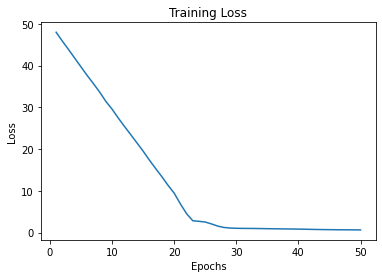

In [5]:
# 학습 진행 이력을 그래프로 보기 : 모델 평가

import matplotlib.pyplot as plt
loss = history.history['loss'] #손실함수의 결과값
epochs = range(1,len(loss)+1)   #학습 횟수

plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.plot(epochs, loss) # 학습 횟수를 x축 값으로, 손실결과값을 y축 값으로
plt.show()

In [6]:
# 테스트용 데이터 읽어오기
df_test = pd.read_excel('사과배-테스트.xlsx')
df_test.fillna(0, inplace=True)
df_test.replace({'fruit':{'사과':0, '배':1}}, inplace=True)
x_test = df_test.iloc[:,1:]
y_test = df_test.iloc[:,0]

In [7]:
prd = model.predict(x_test)
prd

1/1 [==============================] - 0s 66ms/step


array([[9.9995947e-01],
       [9.9942046e-01],
       [9.9909937e-01],
       [7.1917928e-04],
       [3.1241233e-04],
       [1.1045231e-02],
       [9.9873650e-01],
       [2.2729875e-04]], dtype=float32)

In [8]:
df_test['prd'] = prd>0.5
df_test

,fruit,weight,height,width,hardness,sweet,sour,color,prd
0,1,680.0,100.0,111.6,36.8,12.0,0.10,0.0,True
1,1,640.0,99.0,96.3,30.1,12.0,0.20,0.0,True
2,1,599.6,104.1,86.7,31.5,10.1,0.20,0.0,True
3,0,319.0,87.0,89.2,57.7,13.3,0.21,56.1,False
4,0,350.0,89.0,91.8,35.0,13.6,0.31,57.8,False
5,0,270.0,75.0,85.0,37.0,13.3,0.22,55.6,False
6,1,302.6,102.5,55.1,18.7,9.6,0.30,0.0,True
7,0,454.2,99.8,103.6,31.6,14.2,0.20,54.7,False


In [9]:
# 테스트 데이터로 예측 정확도를 확인
loss_value, accuracy = model.evaluate(x_test,y_test)
print('손실값:',loss_value)
print('예측 정확도:', accuracy)

1/1 [==============================] - 0s 116ms/step - loss: 0.0019 - accuracy: 1.0000
손실값: 0.0018939283909276128
예측 정확도: 1.0


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 6)                 48        
                                                                 
 dense_4 (Dense)             (None, 3)                 21        
                                                                 
 dense_5 (Dense)             (None, 1)                 4         
                                                                 
Total params: 73
Trainable params: 73
Non-trainable params: 0
_________________________________________________________________
Epoch 1/50
3/3 [==============================] - 0s 0s/step - loss: 47.9986 - accuracy: 0.6421
Epoch 2/50
3/3 [==============================] - 0s 0s/step - loss: 45.8634 - accuracy: 0.6421
Epoch 3/50
3/3 [==============================] - 0s 0s/step - loss: 43.8419 - accuracy: 0.6421
Epoch 4/50
3/3 [==================

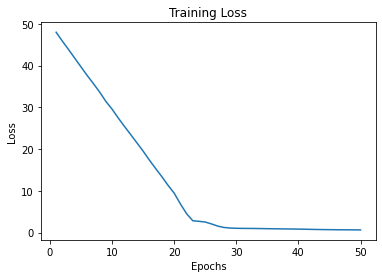

1/1 [==============================] - 0s 83ms/step - loss: 0.0019 - accuracy: 1.0000
손실값: 0.0018939283909276128
예측 정확도: 1.0


In [10]:
# 데이터 수집
import pandas as pd

df = pd.read_excel('사과배-학습.xlsx')
df.fillna(0, inplace=True)
df.replace({'fruit':{'사과':0, '배':1}}, inplace=True)
x_train = df.iloc[:, 1:]
y_train = df.iloc[:,0]

# 딥러닝 모델 구성
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
tf.random.set_seed(0)


x_train.shape

model = Sequential()

model.add(Dense(units=6,input_shape=(7,),activation='relu'))
model.add(Dense(units=3,activation='relu'))
model.add(Dense(units=1,activation='sigmoid'))

model.compile(optimizer = 'Adam', loss = 'binary_crossentropy', 
               metrics=['accuracy'])
model.summary()

#학습
history = model.fit(x_train,y_train,epochs=50)

# 학습 진행 이력을 그래프로 보기
import matplotlib.pyplot as plt
loss = history.history['loss']
epochs = range(1,len(loss)+1)  

plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.plot(epochs, loss) 
plt.show()

# 테스트용 데이터 읽어오기
df_test = pd.read_excel('사과배-테스트.xlsx')
df_test.fillna(0, inplace=True)
df_test.replace({'fruit':{'사과':0, '배':1}}, inplace=True)
x_test = df_test.iloc[:,1:]
y_test = df_test.iloc[:,0]

#예측하기
prd = model.predict(x_test)
prd
df_test['prd'] = prd>0.5
df_test

# 테스트 데이터로 예측 정확도를 확인
loss_value, accuracy = model.evaluate(x_test,y_test)
print('손실값:',loss_value)
print('예측 정확도:', accuracy)